Imports & Load BLIP Model

In [2]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

# Load pretrained BLIP model (image captioning variant)
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

print("BLIP model loaded successfully!")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

D:\Projects\internship-project\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP model loaded successfully!


Load Dataset & Pick Sample Images

In [6]:
captions_path = "../data/captions.txt"
images_dir = "../data/Images"

df = pd.read_csv(captions_path)


sample_images = df['image'].unique()[:8]
print(sample_images)

<ArrowStringArray>
['1000268201_693b08cb0e.jpg', '1001773457_577c3a7d70.jpg',
 '1002674143_1b742ab4b8.jpg', '1003163366_44323f5815.jpg',
 '1007129816_e794419615.jpg', '1007320043_627395c3d8.jpg',
 '1009434119_febe49276a.jpg', '1012212859_01547e3f17.jpg']
Length: 8, dtype: str


Function: Generate Caption With BLIP

In [8]:
def generate_blip_caption(image_path):
    raw_image = Image.open(image_path).convert('RGB')
    inputs = processor(raw_image, return_tensors="pt")
    out = model.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

# Test on one image
test_path = os.path.join(images_dir, sample_images[0])
print("Generated caption:", generate_blip_caption(test_path))

Generated caption: a little girl in a pink dress


 Run BLIP On All Sample Images & Compare With Ground Truth

In [10]:
results = []

for img_name in sample_images:
    img_path = os.path.join(images_dir, img_name)
    ground_truth = df[df['image'] == img_name]['caption'].iloc[0]
    generated = generate_blip_caption(img_path)
    results.append({
        "image": img_name,
        "ground_truth_caption": ground_truth,
        "blip_generated_caption": generated
    })

results_df = pd.DataFrame(results)
results_df

,image,ground_truth_caption,blip_generated_caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,a little girl in a pink dress
1,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting,two dogs playing on the road
2,1002674143_1b742ab4b8.jpg,A little girl covered in paint sits in front o...,a child sitting in the grass
3,1003163366_44323f5815.jpg,A man lays on a bench while his dog sits by him .,a woman laying on a bench
4,1007129816_e794419615.jpg,A man in an orange hat starring at something .,man wearing a hat
5,1007320043_627395c3d8.jpg,A child playing on a rope net .,a young girl climbing on a rope
6,1009434119_febe49276a.jpg,A black and white dog is running in a grassy g...,a dog running in a field
7,1012212859_01547e3f17.jpg,"A dog shakes its head near the shore , a red b...",a dog playing with a ball


Visualize: Images With Generated Captions

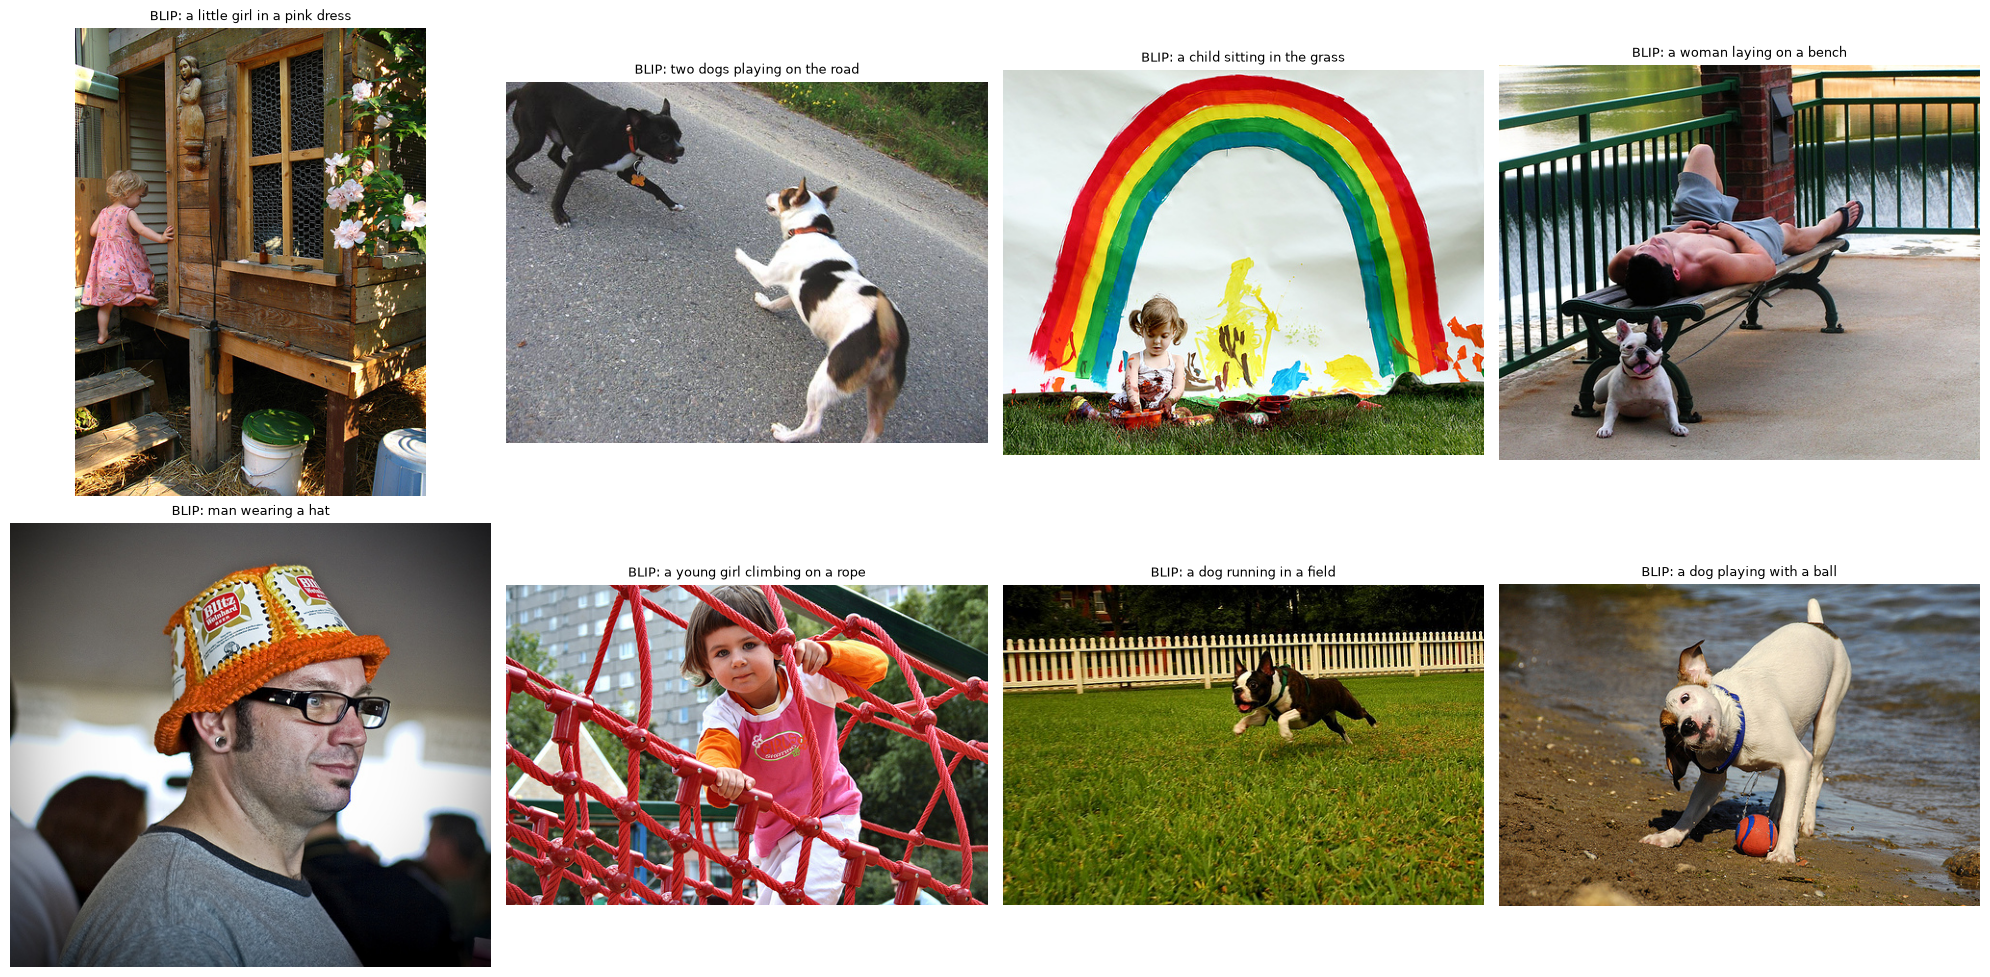

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, row in results_df.iterrows():
    img_path = os.path.join(images_dir, row['image'])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"BLIP: {row['blip_generated_caption']}", fontsize=9, wrap=True)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("blip_zeroshot_samples.png")
plt.show()

Save Results

In [14]:
results_df.to_csv("blip_zeroshot_results.csv", index=False)
print("Saved blip_zeroshot_results.csv")

Saved blip_zeroshot_results.csv


Qualitative Comments
## Qualitative Observations — Zero-Shot BLIP Captioning

Comparing BLIP's zero-shot generated captions against the human-written 
ground truth captions:

- **Strengths:** BLIP generally identifies the main subject and action 
  correctly (e.g., recognizing people, animals, and basic activities) 
  even without any fine-tuning on this dataset.
- **Weaknesses:** Generated captions tend to be shorter and more generic 
  than human captions, sometimes missing specific details (like colors, 
  clothing, or background context) that human annotators included.
- **Overall:** The zero-shot performance is a reasonable baseline, 
  showing the model has strong general visual-language understanding 
  from its pretraining, but fine-tuning on Flickr8k should help it 
  produce more detailed, dataset-style captions.